Классификация курящих по медицинским данным (с feature engeneering)

In [1]:
!pip install -q lightning torchmetrics pandas scikit-learn numpy matplotlib seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.9/44.9 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 846.0/846.0 kB 21.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 24.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 849.5/849.5 kB 31.0 MB/s eta 0:00:00


Импорты и настройки

In [2]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import lightning as L
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
SEED = 2026
L.seed_everything(SEED)
torch.set_float32_matmul_precision('high')

print("Библиотеки загружены")

INFO: Seed set to 2026
INFO:lightning.fabric.utilities.seed:Seed set to 2026


Библиотеки загружены


Функции создания новых признаков

In [3]:
def add_new_features(df):
    """Добавление медицинских признаков"""
    df = df.copy()

    # BMI
    if 'height(cm)' in df and 'weight(kg)' in df:
        df['BMI'] = df['weight(kg)'] / ((df['height(cm)'] / 100) ** 2)

    # Отношение талии к росту
    if 'waist(cm)' in df and 'height(cm)' in df:
        df['Waist_Height'] = df['waist(cm)'] / df['height(cm)']

    # Коэффициент де Ритиса (показатель печени)
    if 'AST' in df and 'ALT' in df:
        df['AST_ALT'] = df['AST'] / (df['ALT'] + 1e-6)

    # Липидные соотношения
    if 'LDL' in df and 'HDL' in df:
        df['LDL_HDL'] = df['LDL'] / (df['HDL'] + 1e-6)

    # Среднее зрение
    if 'eyesight(left)' in df and 'eyesight(right)' in df:
        df['Eyesight_avg'] = (df['eyesight(left)'] + df['eyesight(right)']) / 2

    return df


Загрузка данных



In [5]:
print("Загружаем данные...")
try:
    train_df = pd.read_csv('train.csv')
    test_df = pd.read_csv('test.csv')
    print(f"Данные загружены: {len(train_df)} train, {len(test_df)} test")
except:
    print("Файлы не найдены. Загрузите train.csv и test.csv в Colab")
    raise

Загружаем данные...
Данные загружены: 15000 train, 10000 test


Целевая переменная

In [6]:
target = train_df['smoking'].copy()
train_ids = train_df['id'].copy()
test_ids = test_df['id'].copy()

Удаляем ID

In [7]:
train_df = train_df.drop(['id', 'smoking'], axis=1)
test_df = test_df.drop('id', axis=1)

Создание новых признаков

In [8]:
print("\n🔧 Создаем новые признаки...")
train_df = add_new_features(train_df)
test_df = add_new_features(test_df)
print(f"Признаки созданы. Теперь: {train_df.shape[1]} признаков")


🔧 Создаем новые признаки...
Признаки созданы. Теперь: 27 признаков


Разделение на train/val

In [9]:
X_train, X_val, y_train, y_val = train_test_split(
    train_df, target,
    test_size=0.15,
    random_state=SEED,
    stratify=target
)

Числовые и категориальные признаки

In [10]:
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

Масштабирование числовых признаков

In [11]:
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_val[num_cols] = scaler.transform(X_val[num_cols])
test_df[num_cols] = scaler.transform(test_df[num_cols])

Обработка категориальных признаков

In [12]:
for col in cat_cols:
    le = LabelEncoder()
    all_vals = pd.concat([X_train[col], X_val[col], test_df[col]]).astype(str)
    le.fit(all_vals)
    X_train[col] = le.transform(X_train[col].astype(str))
    X_val[col] = le.transform(X_val[col].astype(str))
    test_df[col] = le.transform(test_df[col].astype(str))

Заполнение пропусков

In [13]:
#стратегия выбрана чтобы избежать смещения из-за возможных выборосов в случае выбора среднего
imputer = SimpleImputer(strategy='median')
X_train = imputer.fit_transform(X_train)
X_val = imputer.transform(X_val)
test_df = imputer.transform(test_df)

Подготовка датасетов

In [14]:
class TabularDataset(Dataset):
    def __init__(self, features, labels=None):
        self.features = torch.FloatTensor(features)
        self.labels = torch.FloatTensor(labels) if labels is not None else None

    def __len__(self):
        return len(self.features)

    def __getitem__(self, idx):
        if self.labels is not None:
            return self.features[idx], self.labels[idx]
        return self.features[idx]

Создание загрузчиков

In [15]:
batch_size = 64
train_dataset = TabularDataset(X_train, y_train.values)
val_dataset = TabularDataset(X_val, y_val.values)
test_dataset = TabularDataset(test_df)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size*2)
test_loader = DataLoader(test_dataset, batch_size=batch_size*2)
print(f"Размеры: train={len(train_dataset)}, val={len(val_dataset)}, test={len(test_dataset)}")

Размеры: train=12750, val=2250, test=10000


Модель классификации

In [16]:
class SmokingClassifier(L.LightningModule):
    def __init__(self, input_dim, pos_weight=1.0):
        super().__init__()
        self.save_hyperparameters()

        # Сеть с регуляризацией
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(64, 1)
        )

        self.criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(pos_weight))
        self.train_preds = []
        self.train_labels = []
        self.val_preds = []
        self.val_labels = []

    def forward(self, x):
        return self.net(x).squeeze(-1)

    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.criterion(logits, y)

        preds = torch.sigmoid(logits).detach()
        self.train_preds.extend(preds.cpu().numpy())
        self.train_labels.extend(y.cpu().numpy())

        self.log('train_loss', loss, prog_bar=True)
        return loss

    def on_train_epoch_end(self):
        if self.train_preds:
            auc = roc_auc_score(self.train_labels, self.train_preds)
            self.log('train_auc', auc, prog_bar=True)
            self.train_preds.clear()
            self.train_labels.clear()

    def validation_step(self, batch, batch_idx):
        x, y = batch
        with torch.no_grad():
            logits = self(x)
            loss = self.criterion(logits, y)
            preds = torch.sigmoid(logits)

        self.val_preds.extend(preds.cpu().numpy())
        self.val_labels.extend(y.cpu().numpy())
        self.log('val_loss', loss, prog_bar=True)
        return loss

    def on_validation_epoch_end(self):
        if self.val_preds:
            auc = roc_auc_score(self.val_labels, self.val_preds)
            self.log('val_auc', auc, prog_bar=True)
            self.val_preds.clear()
            self.val_labels.clear()

    def configure_optimizers(self):
        return torch.optim.AdamW(self.parameters(), lr=5e-4, weight_decay=0.01)


Обучение модели

In [17]:
pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])
print(f"Вес класса 'курящие': {pos_weight:.1f}")

model = SmokingClassifier(input_dim=X_train.shape[1], pos_weight=pos_weight)

checkpoint = L.pytorch.callbacks.ModelCheckpoint(
    monitor='val_auc', mode='max', save_top_k=1
)

early_stop = L.pytorch.callbacks.EarlyStopping(
    monitor='val_auc', patience=10, mode='max'
)

trainer = L.Trainer(
    max_epochs=60,
    callbacks=[checkpoint, early_stop],
    log_every_n_steps=20,
    gradient_clip_val=1.0,
    accelerator='auto'
)

trainer.fit(model, train_loader, val_loader)

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores


Вес класса 'курящие': 1.7


INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ net       │ Sequential        │ 49.3 K │ train │     0 │
│ 1 │ criterion │ BCEWithLogitsLoss │      0 │ train │     0 │
└───┴───────────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 49.3 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 49.3 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 15                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

Загрузка лучшей модели

In [18]:
if checkpoint.best_model_path:
    model = SmokingClassifier.load_from_checkpoint(
        checkpoint.best_model_path,
        input_dim=X_train.shape[1],
        pos_weight=pos_weight
    )

Предсказания и сохранение

In [19]:
model.eval()
preds = []

with torch.no_grad():
    for batch in test_loader:
        x = batch.to(model.device)
        logits = model(x)
        probs = torch.sigmoid(logits).cpu().numpy()
        preds.extend(probs)

# Сохранение результатов
submission = pd.DataFrame({'id': test_ids, 'smoking': preds})
submission.to_csv('submission.csv', index=False)

print(f"Сохранено: submission.csv")
print(f"Среднее предсказание: {np.mean(preds):.4f}")

Сохранено: submission.csv
Среднее предсказание: 0.4283


График распределения

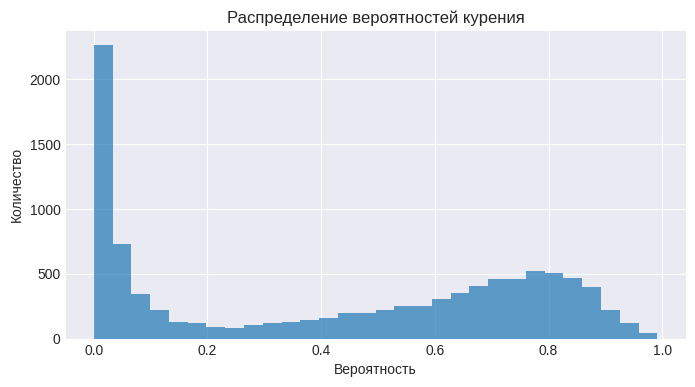

In [20]:
plt.figure(figsize=(8, 4))
plt.hist(preds, bins=30, alpha=0.7)
plt.title('Распределение вероятностей курения')
plt.xlabel('Вероятность')
plt.ylabel('Количество')
plt.show()

Анализ важности признаков

Базовый AUC: 0.8470


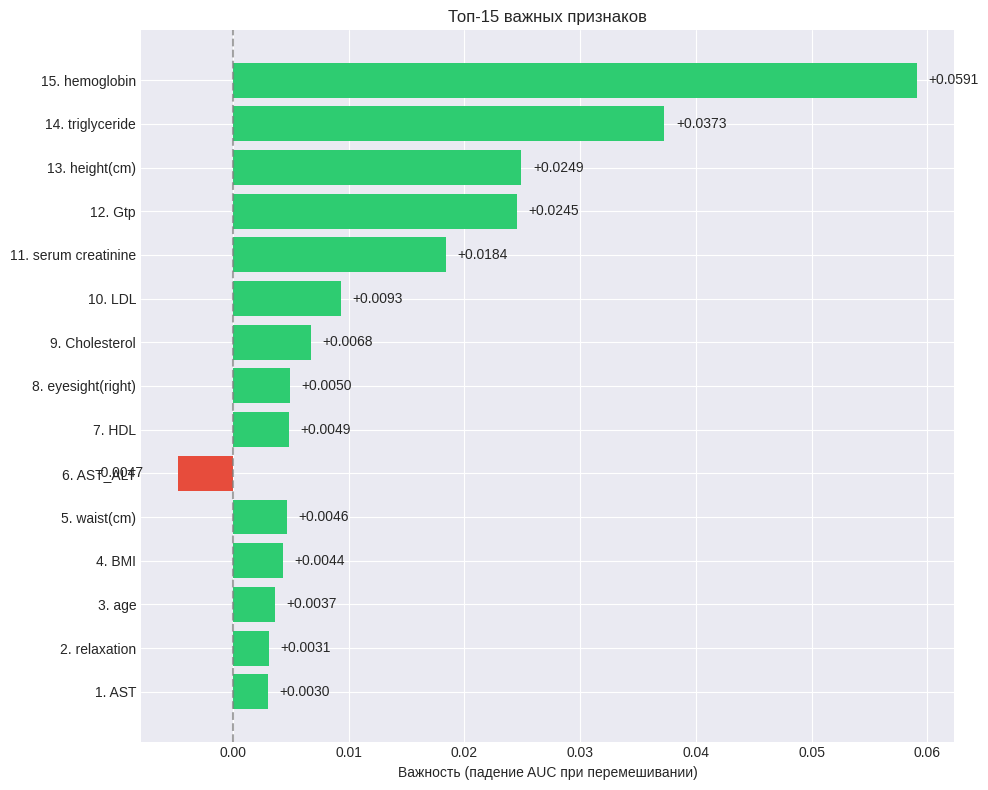


⭐ Анализ новых признаков:
  ⚠️ Слабый: AST_ALT                   | Важность: -0.0047
  ⚠️ Слабый: BMI                       | Важность: +0.0044
  ⚠️ Слабый: Waist_Height              | Важность: +0.0017
  ⚠️ Слабый: LDL_HDL                   | Важность: -0.0007
  ⚠️ Слабый: Eyesight_avg              | Важность: +0.0005


In [29]:
feature_names = list(train_df.columns)  # Используем исходные имена колонок

def permutation_importance(model, X, y, feature_names, n_samples=500):
    """Вычисление важности признаков методом перестановок"""
    model.eval()

    # Берем подвыборку для скорости
    if len(X) > n_samples:
        indices = np.random.choice(len(X), n_samples, replace=False)
        X_sample = X[indices]
        y_sample = y[indices]
    else:
        X_sample = X
        y_sample = y

    X_tensor = torch.FloatTensor(X_sample).to(model.device)
    with torch.no_grad():
        logits = model(X_tensor)
        base_probs = torch.sigmoid(logits).cpu().numpy()
        base_auc = roc_auc_score(y_sample, base_probs)

    print(f"Базовый AUC: {base_auc:.4f}")
    importances = []

    # Перестановка каждого признака
    for i, feature in enumerate(feature_names):
        X_perm = X_sample.copy()
        np.random.shuffle(X_perm[:, i])  # Перемешиваем i-й признак

        X_perm_tensor = torch.FloatTensor(X_perm).to(model.device)
        with torch.no_grad():
            logits = model(X_perm_tensor)
            probs = torch.sigmoid(logits).cpu().numpy()
            perm_auc = roc_auc_score(y_sample, probs)

        # Важность = падение AUC
        importance = base_auc - perm_auc
        importances.append((feature, importance))

    importances.sort(key=lambda x: abs(x[1]), reverse=True)
    return importances, base_auc

# Вычисляем важность
importances, base_auc = permutation_importance(
    model, X_val, y_val.values, feature_names, n_samples=300
)

# Визуализация топ-15 признаков
top_n = 15
top_features = [f[0] for f in importances[:top_n]]
top_importances = [f[1] for f in importances[:top_n]]

plt.figure(figsize=(10, 8))
bars = plt.barh(range(len(top_features)), top_importances[::-1],
                color=['#2ecc71' if x > 0 else '#e74c3c' for x in top_importances[::-1]])

plt.yticks(range(len(top_features)), [f"{i+1}. {name}" for i, name in enumerate(top_features[::-1])])
plt.xlabel('Важность (падение AUC при перемешивании)')
plt.title(f'Топ-{top_n} важных признаков')
plt.axvline(x=0, color='gray', linestyle='--', alpha=0.7)

for i, bar in enumerate(bars):
    width = bar.get_width()
    plt.text(width + 0.001 if width > 0 else width - 0.003,
             bar.get_y() + bar.get_height()/2,
             f'{width:+.4f}',
             ha='left' if width > 0 else 'right',
             va='center')

plt.tight_layout()
plt.show()


new_features_keywords = ['BMI', 'Waist_Height', 'AST_ALT', 'LDL_HDL', 'Eyesight_avg', 'ratio', 'avg', 'diff']
new_features = [f for f in feature_names if any(kw in f for kw in new_features_keywords)]

if new_features:
    print("\n⭐ Анализ новых признаков:")
    for feature, imp in importances:
        if feature in new_features:
            status = "✅ Важный" if abs(imp) > 0.005 else "⚠️ Слабый"
            print(f"  {status}: {feature:25s} | Важность: {imp:+.4f}")
else:
    print("\nℹ️ Нет новых признаков для анализа")

# Сохраняем важность в файл
importance_df = pd.DataFrame(importances, columns=['feature', 'importance'])
importance_df.to_csv('feature_importance.csv', index=False)

In [21]:
try:
    from google.colab import files
    files.download('submission.csv')
    print("Файл готов к скачиванию")
except:
    print("Файл сохранен в текущей директории")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Файл готов к скачиванию


Оценка на валидации

ROC AUC на валидации: 0.8803

Дополнительные метрики:
  Accuracy:  0.7862
  Precision: 0.6569
  Recall:    0.8861
  F1-Score:  0.7545


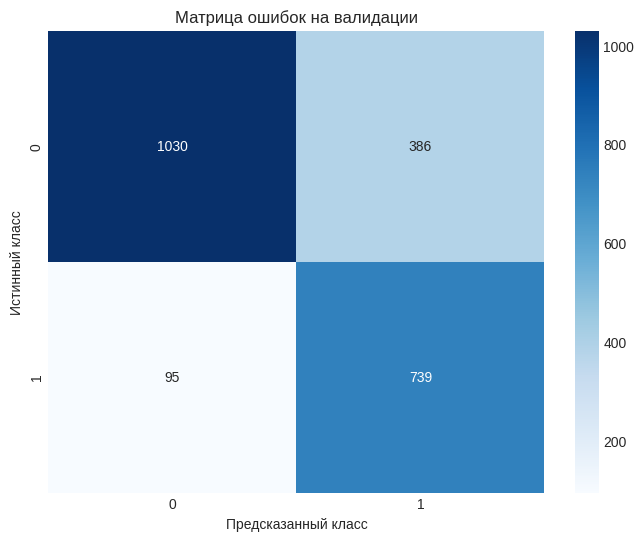

In [23]:
model.eval()
val_preds = []
val_labels = []

with torch.no_grad():
    for batch in val_loader:
        x, y = batch
        x = x.to(model.device)
        logits = model(x)
        probs = torch.sigmoid(logits).cpu().numpy()
        val_preds.extend(probs)
        val_labels.extend(y.numpy())

# Вычисление ROC AUC
try:
    val_auc = roc_auc_score(val_labels, val_preds)
    print(f"ROC AUC на валидации: {val_auc:.4f}")

    val_preds_binary = (np.array(val_preds) > 0.5).astype(int)
    val_labels_binary = (np.array(val_labels) > 0.5).astype(int)

    accuracy = (val_preds_binary == val_labels_binary).mean()
    precision = (val_preds_binary & val_labels_binary).sum() / max(val_preds_binary.sum(), 1)
    recall = (val_preds_binary & val_labels_binary).sum() / max(val_labels_binary.sum(), 1)
    f1_score = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

    print(f"\nДополнительные метрики:")
    print(f"  Accuracy:  {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-Score:  {f1_score:.4f}")

    from sklearn.metrics import confusion_matrix
    cm = confusion_matrix(val_labels_binary, val_preds_binary)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title('Матрица ошибок на валидации')
    plt.ylabel('Истинный класс')
    plt.xlabel('Предсказанный класс')
    plt.show()

except Exception as e:
    print(f"Ошибка при вычислении метрик: {e}")
